<h1>Extracting and Visualizing Stock Data</h1>

## Stock Price and Revenue Analysis using Python

## Project Objective

The objective of this project is to analyze the relationship between stock prices and company revenue for Tesla and GameStop.

This project demonstrates:
- Data extraction using yfinance
- Web scraping using BeautifulSoup
- Data cleaning using Pandas
- Data visualization using Matplotlib
- Basic financial data analysis

In [1]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib

  Using cached yfinance-1.5.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.1.1-py3-none-any.whl.metadata (10 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
Using cached yfinance-1.5.1-py2.py3-none-any.whl (144 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.1.1-py3-none-any.whl (170 kB)

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ----------------------------------

In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

Ignore warnings using the warnings module. Used the filterwarnings function to filter or ignore specific warning messages or categories.


In [3]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Define Graphing Function


Defined the function `make_graph`. **It takes a dataframe with stock data, a dataframe with revenue data and the name of the stock.**

In [38]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

## Using yfinance to Extract Stock Data


Using the `Ticker` function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is Tesla and its ticker symbol is `TSLA`.


In [4]:
Tesla = yf.Ticker("TSLA")

Using the ticker object and the function `history` extract stock information and save it in a dataframe named `tesla_data`. Set the `period` parameter to ` "max" ` so we get information for the maximum amount of time.


In [5]:
Tesla_data = Tesla.history(period="max")

**Reset the index** using the `reset_index(inplace=True)` function on the tesla_data DataFrame and display the first five rows of the `tesla_data` dataframe using the `head` function. 


In [6]:
Tesla_data.reset_index(inplace=True)

In [8]:
Tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Using Webscraping to Extract Tesla Revenue Data


In [9]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

In [10]:
data  = requests.get(url).text
print(data)


<!DOCTYPE html>
<!--[if lt IE 7]>      <html class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js"> <!--<![endif]-->
    <head>
        <meta charset="utf-8">
        <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
		<link rel="canonical" href="https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue" />
		<title>Tesla Revenue 2010-2022 | TSLA | MacroTrends</title>
		<meta name="description" content="Tesla annual/quarterly revenue history and growth rate from 2010 to 2022. Revenue can be defined as the amount of money a company receives from its customers in exchange for the sales of goods or services.  Revenue is the top line item on an income statement from which all costs and expenses are subtracted to arrive at net income.    
				
				&lt;ul style='margin-top:10px;'&gt;
				&lt;li&gt;Tesla r

Parse the html data using `beautiful_soup` using parser i.e `html5lib` or `html.parser`.


In [11]:
soup = BeautifulSoup(data, 'html.parser')

Using `BeautifulSoup` or the `read_html` function extract the table with `Tesla Revenue` and store it into a dataframe named `tesla_revenue`. The dataframe should have columns `Date` and `Revenue`.


In [12]:
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])
tesla_revenue

,Date,Revenue


In [13]:
# First we isolate the body of the table which contains all the information
# Then we loop through each row and find all the column values for each row
for row in soup.find("tbody").find_all('tr'):
    col = row.find_all("td")
    date = col[0].text
    Revenue = col[1].text
    
    # Finally we append the data of each row to the table
    tesla_revenue = pd.concat([tesla_revenue,pd.DataFrame({"Date":[date], "Revenue":[Revenue]})], ignore_index=True)    

In [16]:
tesla_revenue.head()

,Date,Revenue
0,2021,"$53,823"
1,2020,"$31,536"
2,2019,"$24,578"
3,2018,"$21,461"
4,2017,"$11,759"


Executing the following line to remove the comma and dollar sign from the `Revenue` column. 


In [32]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)

Executing the following lines to remove an null or empty strings in the Revenue column.


In [33]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

Displaying the last 5 row of the `tesla_revenue` dataframe using the `tail` function. 

In [34]:
tesla_revenue.tail()

,Date,Revenue
8,2013,2013
9,2012,413
10,2011,204
11,2010,117
12,2009,112


## Using yfinance to Extract Stock Data


Using the `Ticker` function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is GameStop and its ticker symbol is `GME`.


In [18]:
GameStop = yf.Ticker("GME")

Using the ticker object and the function `history` extract stock information and save it in a dataframe named `gme_data`. Set the `period` parameter to ` "max" ` so we get information for the maximum amount of time.


In [19]:
gme_data = GameStop.history(period="max")

**Reset the index** using the `reset_index(inplace=True)` function on the gme_data DataFrame and display the first five rows of the `gme_data` dataframe using the `head` function. 


In [39]:
gme_data.reset_index(inplace=True)
gme_data.head()

,index,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,0,2002-02-13 00:00:00-05:00,1.620128,1.693349,1.603295,1.691666,76216000,0.0,0.0
1,1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Using Webscraping to Extract GME Revenue Data


In [21]:
url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

In [22]:
data  = requests.get(url_gme).text
print(data)

<!DOCTYPE html>
<!-- saved from url=(0105)https://web.archive.org/web/20200814131437/https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue -->
<html class=" js flexbox canvas canvastext webgl no-touch geolocation postmessage websqldatabase indexeddb hashchange history draganddrop websockets rgba hsla multiplebgs backgroundsize borderimage borderradius boxshadow textshadow opacity cssanimations csscolumns cssgradients cssreflections csstransforms csstransforms3d csstransitions fontface generatedcontent video audio localstorage sessionstorage webworkers no-applicationcache svg inlinesvg smil svgclippaths" style=""><!--<![endif]--><head><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><script type="text/javascript" async="" src="./GameStop Revenue 2006-2020 _ GME _ MacroTrends_files/analytics.js.download"></script><script async="" type="text/javascript" src="./GameStop Revenue 2006-2020 _ GME _ MacroTrends_files/gpt.js.download"></script><script async="" src="./

Parse the html data using `beautiful_soup` using parser i.e `html5lib` or `html.parser`.


In [24]:
soup = BeautifulSoup(data, 'html.parser')

Using `BeautifulSoup` or the `read_html` function extract the table with `GameStop Revenue` and store it into a dataframe named `gme_revenue`. The dataframe should have columns `Date` and `Revenue`. And the comma and dollar sign is removed from the `Revenue` column.


In [25]:
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])
gme_revenue

,Date,Revenue


In [26]:
# First we isolate the body of the table which contains all the information
# Then we loop through each row and find all the column values for each row
for row in soup.find("tbody").find_all('tr'):
    col = row.find_all("td")
    date = col[0].text
    Revenue = col[1].text
    
    # Finally we append the data of each row to the table
    gme_revenue = pd.concat([gme_revenue,pd.DataFrame({"Date":[date], "Revenue":[Revenue]})], ignore_index=True)    

In [27]:
gme_revenue.head()

,Date,Revenue
0,2020,"$6,466"
1,2019,"$8,285"
2,2018,"$8,547"
3,2017,"$7,965"
4,2016,"$9,364"


In [28]:
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"",regex=True)

In [29]:
gme_revenue.dropna(inplace=True)

gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

Displaing the last five rows of the `gme_revenue` dataframe using the `tail` function.

In [30]:
gme_revenue.tail()

,Date,Revenue
11,2009,8806
12,2008,7094
13,2007,5319
14,2006,3092
15,2005,1843


## Ploting Tesla Stock Graph


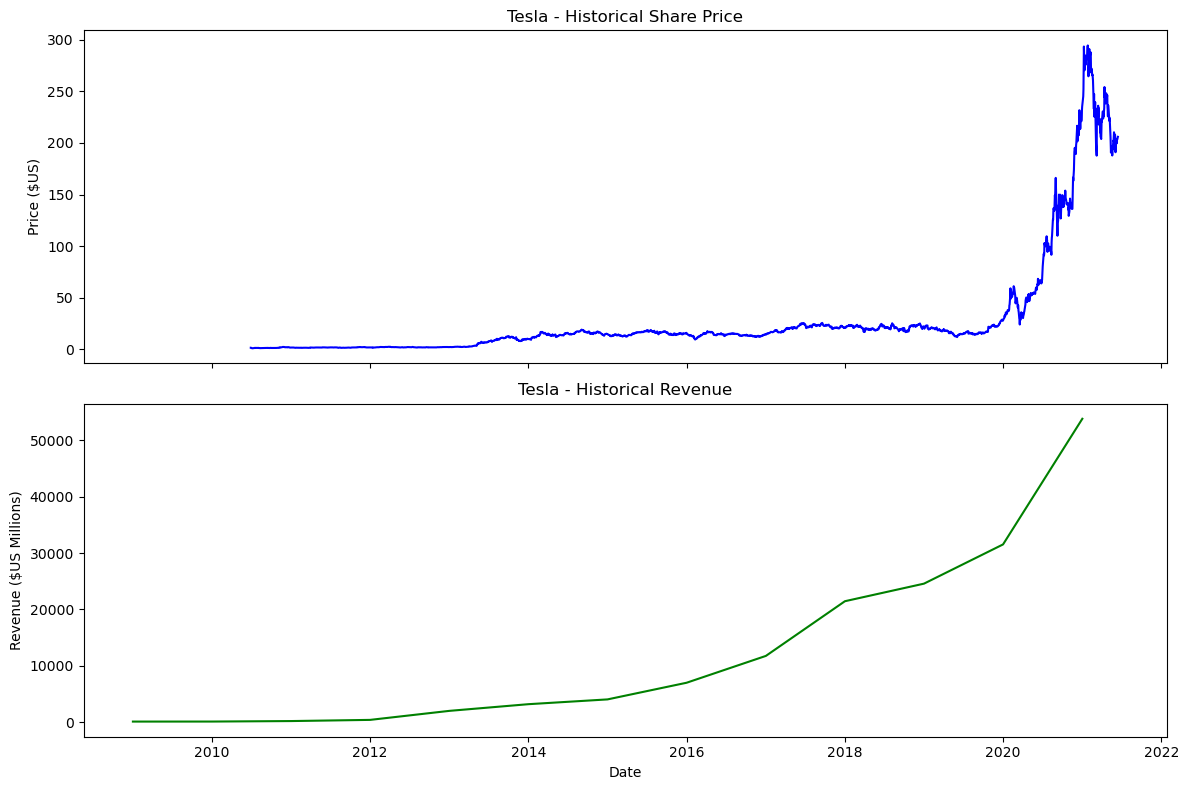

In [54]:
make_graph(Tesla_data, tesla_revenue, 'Tesla')

## Tesla Stock Price vs Revenue Insights :
1. Tesla's revenue increased significantly over the years, reflecting strong business growth.
2. The stock price also showed a long-term upward trend, indicating growing investor confidence.
3. This analysis suggests that improving business performance was accompanied by an increase in the company's market value.

Business Question Answered:
Does Tesla's financial growth align with its stock market performance?

## Tesla 30-Day Moving Average

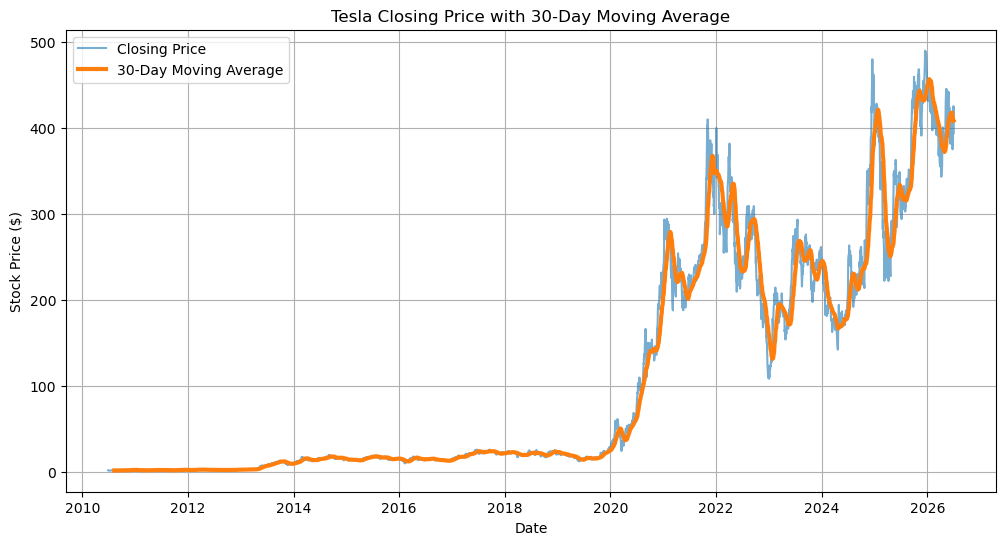

In [48]:
plt.figure(figsize=(12,6))

plt.plot(Tesla_data['Date'], Tesla_data['Close'],
         label='Closing Price',
         alpha=0.6)

plt.plot(Tesla_data['Date'], Tesla_data['MA30'],
         label='30-Day Moving Average',
         linewidth=3)

plt.title("Tesla Closing Price with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.grid(True)
plt.show()

## Tesla 30-Day Moving Average Insights :
1. The 30-day moving average smooths short-term price fluctuations and highlights the long-term trend.
2. The chart shows that Tesla experienced sustained growth despite periods of market volatility.
3. This helps investors identify the overall market direction without being influenced by daily price changes.

Business Question Answered:
What is Tesla's long-term stock price trend?

## Ploting GameStop Stock Graph


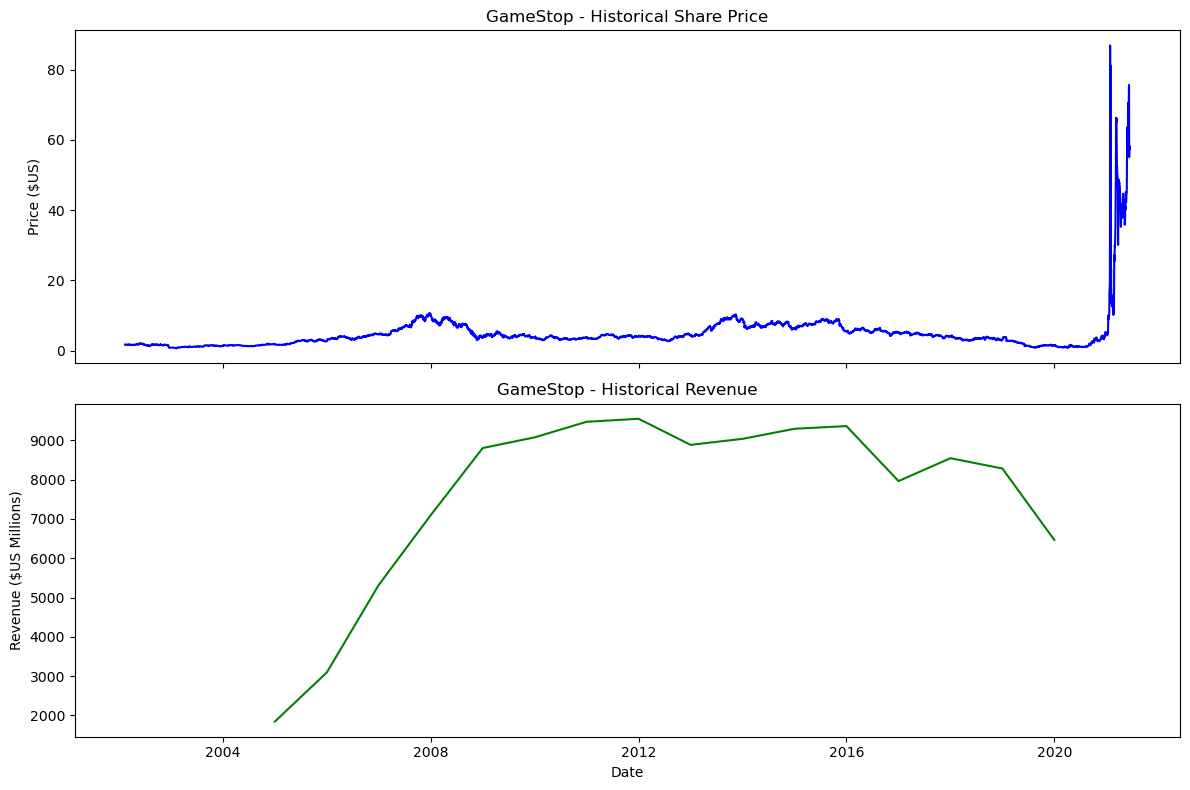

In [36]:
make_graph(gme_data, gme_revenue, 'GameStop')

## GameStop Stock Price vs Revenue Insights
1. GameStop's revenue remained relatively stable or declined during several periods.
2. However, the stock price experienced sharp fluctuations that were not supported by revenue growth.
3. This indicates that market sentiment and investor behavior had a stronger influence on the stock price than the company's financial performance.

Business Question Answered:
Is GameStop's stock price driven by business performance or market sentiment?

## GameStop 30-Day Moving Average

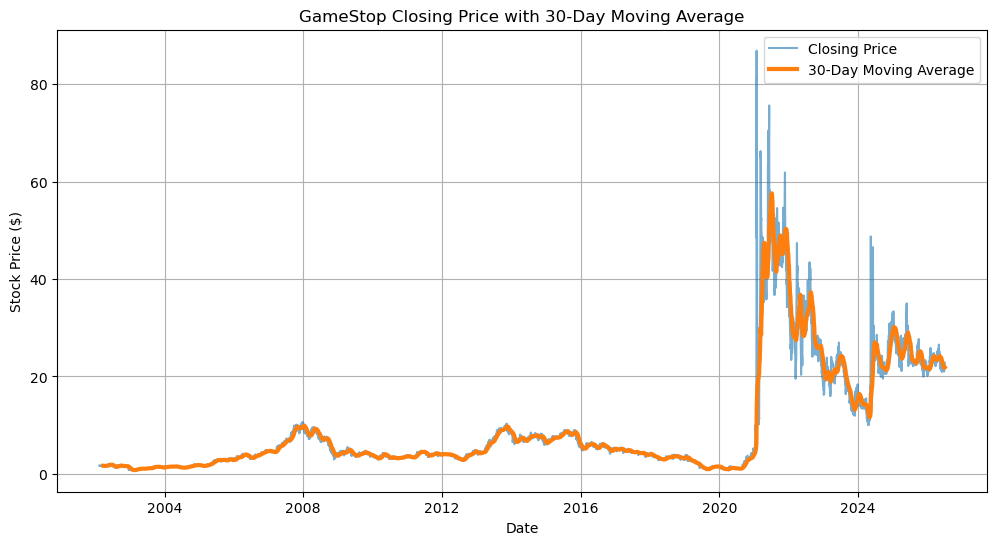

In [52]:
gme_data['MA30'] = gme_data['Close'].rolling(window=30).mean()

plt.figure(figsize=(12,6))

plt.plot(gme_data['Date'], gme_data['Close'],
         label='Closing Price',
         alpha=0.6)

plt.plot(gme_data['Date'], gme_data['MA30'],
         label='30-Day Moving Average',
         linewidth=3)

plt.title("GameStop Closing Price with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.grid(True)
plt.show()

## GameStop 30-Day Moving Average Insights
1. The moving average reduces daily price volatility and reveals the overall trend of GameStop's stock.
2. Despite short-term price spikes, the moving average shows the underlying direction of the stock over time.
3. This helps distinguish temporary market fluctuations from longer-term trends.

Business Question Answered:
What is the long-term trend of GameStop's stock despite daily fluctuations?

## Conclusion

This project demonstrates how financial data can be collected, cleaned, and analyzed using Python.

Key findings:
- Tesla showed consistent revenue and stock price growth.
- GameStop exhibited high stock price volatility despite limited revenue growth.
- The 30-Day Moving Average effectively highlights long-term market trends.